In [17]:
import pandas as pd
data = "../data/preprocessed/preprocessed_data(1).csv"
df = pd.read_csv(data)
df

,Gender,Year,STEM_Major,Diet_Quality,Internet_Quality,Employment,Stress_Level,AI_Tool_Usage,GPA,Performance_Tier,...,Resource_Quality,Focus_Ratio,Stress_Wellbeing,AI_Engagement,Lifestyle_Index,Study_Consistency,Time_Efficiency,Digital_Balance,Academic_Momentum,Stress_Load
0,1,2.0,1,3,3,0,5.5,3,3.39,2,...,9,1.904762,0.500000,34.5,0.658730,1,0.615385,1.428571,11.5,13.0625
1,0,1.0,1,4,3,0,5.5,4,3.69,2,...,12,1.250000,0.458333,42.0,0.773810,3,0.923077,2.500000,31.5,10.3125
2,1,1.0,1,2,3,0,7.5,3,3.48,2,...,6,0.980392,1.071429,37.5,0.448413,4,0.705882,0.588235,25.0,38.4375
3,1,2.0,1,3,3,0,5.5,4,3.50,2,...,9,0.487805,1.000000,44.8,0.500000,6,0.923077,0.975610,33.6,24.0625
4,1,2.0,1,2,2,0,7.5,4,3.70,2,...,4,0.784314,1.250000,44.8,0.333333,6,1.411765,0.784314,33.6,46.8750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
593,0,3.0,1,2,2,0,5.5,4,3.96,2,...,4,2.500000,0.500000,38.0,0.492063,0,1.846154,1.111111,28.5,19.9375
594,1,1.0,1,3,2,0,5.5,3,3.93,2,...,6,0.833333,0.458333,31.5,0.607143,3,0.461538,0.833333,31.5,21.3125
595,1,1.0,1,3,3,0,5.5,4,3.98,2,...,9,0.606061,0.550000,50.0,0.626984,9,1.846154,0.606061,37.5,36.4375
596,1,2.0,1,3,3,1,3.5,2,3.63,2,...,9,1.176471,0.318182,25.0,0.658730,9,2.666667,0.392157,37.5,18.8125


In [18]:
# ════════════════════════════════════════════
# 1. INTERACTION FEATURES
# ════════════════════════════════════════════
# Study quality × consistency = sustained quality
df['Quality_Consistency']     = df['Study_Quality'] * df['Study_Consistency']

# AI usage × engagement = effective AI leverage
df['AI_Leverage']             = df['AI_Enhanced_Study'] * df['AI_Engagement']

# Focus × time efficiency = productive focus
df['Productive_Focus']        = df['Focus_Ratio'] * df['Time_Efficiency']

# Momentum × consistency = academic stability
df['Academic_Stability']      = df['Academic_Momentum'] * df['Study_Consistency']
df['Study_Output']   = df['Study_Quality'] * df['Total_Productive_Hrs']
df['Learning_Power'] = df['Resource_Quality'] * df['AI_Enhanced_Study'] * df['Study_Consistency']

# ════════════════════════════════════════════
# 2. RATIO FEATURES
# ════════════════════════════════════════════
# Productive hours vs distraction hours
df['Productivity_Ratio']      = df['Total_Productive_Hrs'] / (df['Distraction_Hrs'] + 1)

# Wellbeing relative to stress
df['Wellbeing_Stress_Ratio']  = df['Wellbeing_Score'] / (df['Stress_Load'] + 1)

# ════════════════════════════════════════════
# 3. PENALTY FEATURES
# ════════════════════════════════════════════
# High stress + low wellbeing = bad combo
df['Stress_Penalty']          = df['Stress_Load'] * (1 - df['Lifestyle_Index'])

# Employed + high distraction = time pressure
df['Time_Pressure']           = df['Employment'] * df['Distraction_Hrs']



# ════════════════════════════════════════════
# 5. BINARY FLAGS
# ════════════════════════════════════════════
df['High_Distraction']        = (df['Distraction_Hrs'] > df['Distraction_Hrs'].median()).astype(int)
df['High_AI_User']            = (df['AI_Engagement'] > df['AI_Engagement'].median()).astype(int)
df['Low_Stress']              = (df['Stress_Load'] < df['Stress_Load'].median()).astype(int)
df['Consistent_Studier']      = (df['Study_Consistency'] > df['Study_Consistency'].median()).astype(int)

# ── Final X and y ──
X_reg = df.drop(columns=['GPA'])
y_reg = df['GPA']

print(f"Features before engineering : 28")
print(f"Features after engineering  : {X_reg.shape[1]}")
print(f"Target (GPA) range          : {y_reg.min():.2f} – {y_reg.max():.2f}")
print(f"Target (GPA) mean           : {y_reg.mean():.2f}")
print(f"\nNew features added:")
new_features = ['Quality_Consistency', 'AI_Leverage', 'Productive_Focus',
                'Academic_Stability', 'Productivity_Ratio', 'Wellbeing_Stress_Ratio',
                'Stress_Penalty', 'Time_Pressure', 'Study_Quality_Sq',
                'Academic_Momentum_Sq', 'Stress_Load_Sq', 'High_Distraction',
                'High_AI_User', 'Low_Stress', 'Consistent_Studier']
for f in new_features:
    print(f"  + {f}")

Features before engineering : 28
Features after engineering  : 41
Target (GPA) range          : 1.20 – 4.00
Target (GPA) mean           : 2.97

New features added:
  + Quality_Consistency
  + AI_Leverage
  + Productive_Focus
  + Academic_Stability
  + Productivity_Ratio
  + Wellbeing_Stress_Ratio
  + Stress_Penalty
  + Time_Pressure
  + Study_Quality_Sq
  + Academic_Momentum_Sq
  + Stress_Load_Sq
  + High_Distraction
  + High_AI_User
  + Low_Stress
  + Consistent_Studier


In [19]:
df.shape

(598, 42)

In [20]:
from sklearn.feature_selection import SelectKBest, f_regression

X = df.drop(['GPA', 'Performance_Tier'], axis=1)
Y = df['GPA']

# ❌ Remove: X_selected = SelectKBest(...).fit(X, Y)  ← leaks test data
# Just define it here, fit inside Cell 5 after split
X_selector = SelectKBest(score_func=f_regression, k=10)

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, 
)

# Fit selector ONLY on train
X_selected_train = X_selector.fit_transform(X_train, y_train)
X_selected_test = X_selector.transform(X_test)

print(X_train.columns[X_selector.get_support(indices=True)])

Index(['Active_Engagement_Score', 'Study_Quality', 'Resource_Quality',
       'Lifestyle_Index', 'Academic_Momentum', 'Stress_Load',
       'Quality_Consistency', 'AI_Leverage', 'Learning_Power',
       'Stress_Penalty'],
      dtype='str')


In [22]:
from sklearn.preprocessing import StandardScaler
s = StandardScaler()
X_train_scaled = s.fit_transform(X_selected_train)
X_test_scaled = s.transform(X_selected_test)
X_train_scaled

array([[ 0.99887846, -0.4135756 , -0.03856927, ..., -1.1342412 ,
        -0.68845431,  1.33130704],
       [-0.09572013, -1.31114262, -0.93063912, ..., -1.1342412 ,
        -0.68845431, -0.04352157],
       [-0.09572013, -0.4135756 , -0.03856927, ..., -0.40649315,
        -0.45532979, -0.28775358],
       ...,
       [-0.09572013,  0.03520791, -1.22799574, ..., -0.64907583,
        -0.61074614, -1.02603088],
       [-1.35450851,  0.70838318, -0.03856927, ..., -0.28173634,
        -0.68845431, -0.15577867],
       [-1.62815815, -1.31114262, -0.03856927, ..., -1.1342412 ,
        -0.68845431, -1.0411859 ]], shape=(478, 10))

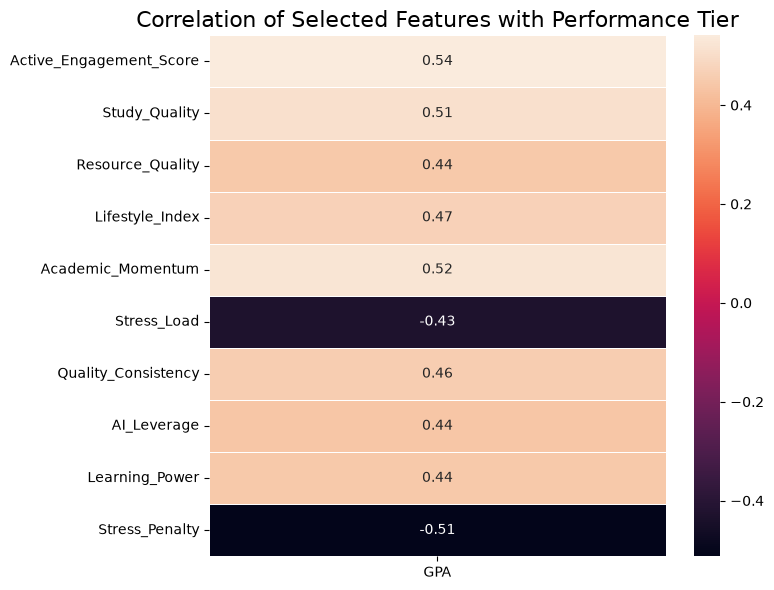

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
# ✅ use X_selector (the SelectKBest object), not X_selected_train (the array)
selected_mask = X_selector.get_support()
selected_features = X_train.columns[selected_mask]

# Rebuild as DataFrame and add target
df_selected = pd.DataFrame(X_selected_train, columns=selected_features)
df_selected['GPA'] = y_train.values

# Plot correlation with Performance_Tier only
plt.figure(figsize=(8, 6))
corr = df_selected.corr()[['GPA']].drop('GPA')
sns.heatmap(corr,annot=True, linewidth=.5)
plt.title('Correlation of Selected Features with Performance Tier', fontsize=16)
plt.tight_layout()
plt.show()

In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(alpha=0.001),
    'Random Forest': RandomForestRegressor(max_depth=10, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(max_depth=10, random_state=42, learning_rate=0.1),
    'XGBoost': XGBRegressor(learning_rate=0.1, random_state=42)
}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    score = model.score(X_test_scaled, y_test)
    print(f"{name}: R^2 Score = {score:.4f}")

Linear Regression: R^2 Score = 0.5160
Ridge Regression: R^2 Score = 0.5165
Lasso Regression: R^2 Score = 0.5176
Random Forest: R^2 Score = 0.4881
Gradient Boosting: R^2 Score = 0.3473
XGBoost: R^2 Score = 0.4156


=== GPA Predictions ===
Profile      | Predicted GPA |  Grade
--------------------------------------
At Risk      |        3.0412 |      B
Moderate     |        2.9249 |      C
Excellent    |        3.4590 |      B


d:\AUPP\Junior\Summer-2026\ITM390-MachineLearning\FinalProject\Academic-Predictor-machine-based-on-performance-\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
d:\AUPP\Junior\Summer-2026\ITM390-MachineLearning\FinalProject\Academic-Predictor-machine-based-on-performance-\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
d:\AUPP\Junior\Summer-2026\ITM390-MachineLearning\FinalProject\Academic-Predictor-machine-based-on-performance-\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


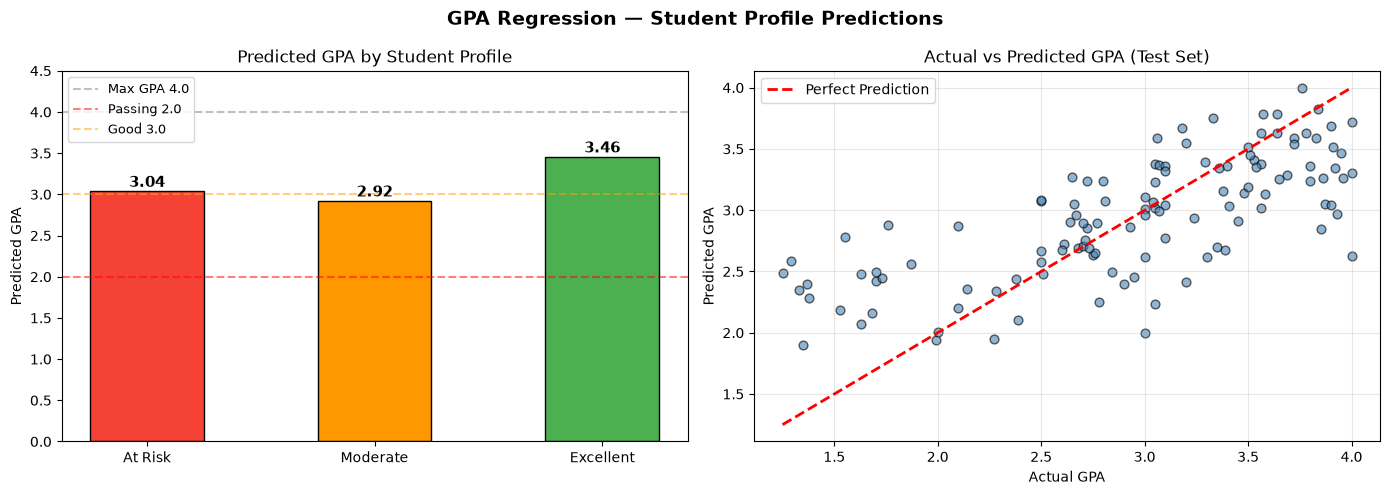

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# ── Real median values per tier (use as reference) ──
# Tier 0 = At Risk | Tier 1 = Moderate | Tier 2 = Excellent
poor_student = {
    "Active_Engagement_Score" : 18.7,
    "Study_Quality"           : 4.0,
    "Resource_Quality"        : 4.0,
    "Lifestyle_Index"         : 9.18,
    "Academic_Momentum"       : 10.5,
    "Stress_Load"             : 6.9,
    "Quality_Consistency"     : 2.0  * 4.0,   # Study_Quality * Study_Consistency
    "AI_Leverage"             : 6.0  * 33.0,  # AI_Enhanced_Study * AI_Engagement
    "Learning_Power"          : 4.0  * 5.0 * 3.0,  # Resource * AI * Consistency
    "Stress_Penalty"          : (1 - 0.18),
}

moderate_student = {
    "Active_Engagement_Score" : 10.5,
    "Study_Quality"           : 4.0,
    "Resource_Quality"        : 4.0,
    "Lifestyle_Index"         : 0.42,
    "Academic_Momentum"       : 21.0,
    "Stress_Load"             : 28.2,
    "Quality_Consistency"     : 4.0  * 2.0,
    "AI_Leverage"             : 6.0  * 33.6,
    "Learning_Power"          : 4.0  * 6.0 * 2.0,
    "Stress_Penalty"          : (1 - 0.42),
}

excellent_student = {
    "Active_Engagement_Score" : 11.5,
    "Study_Quality"           : 8.0,
    "Resource_Quality"        : 8.0,
    "Lifestyle_Index"         : 0.55,
    "Academic_Momentum"       : 31.5,
    "Stress_Load"             : 19.9,
    "Quality_Consistency"     : 8.0  * 4.0,
    "AI_Leverage"             : 9.0  * 37.5,
    "Learning_Power"          : 8.0  * 9.0 * 4.0,
    "Stress_Penalty"          : (1 - 0.55),
}

# ── Predict all 3 profiles ──
profiles     = {'At Risk': poor_student, 'Moderate': moderate_student, 'Excellent': excellent_student}
best_model   = models[ 'Lasso Regression']   # swap to 'Ridge' if you prefer
colors_pred  = ['#F44336', '#FF9800', '#4CAF50']
predictions  = {}

print("=== GPA Predictions ===")
print(f"{'Profile':<12} | {'Predicted GPA':>13} | {'Grade':>6}")
print("-" * 38)
for (profile_name, student), color in zip(profiles.items(), colors_pred):
    student_df     = pd.DataFrame([student])
    student_scaled = s.transform(student_df)
    gpa_pred       = best_model.predict(student_scaled)[0]
    predictions[profile_name] = gpa_pred
    grade = 'A' if gpa_pred >= 3.6 else 'B' if gpa_pred >= 3.0 else 'C' if gpa_pred >= 2.5 else 'D' if gpa_pred >= 2.0 else 'F'
    print(f"{profile_name:<12} | {gpa_pred:>13.4f} | {grade:>6}")

# ── Visualization ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('GPA Regression — Student Profile Predictions', fontsize=14, fontweight='bold')

# Plot 1 — Predicted GPA per profile
bars = axes[0].bar(predictions.keys(), predictions.values(),
                   color=colors_pred, edgecolor='black', width=0.5)
axes[0].axhline(4.0, color='gray',   linestyle='--', alpha=0.5, label='Max GPA 4.0')
axes[0].axhline(2.0, color='red',    linestyle='--', alpha=0.5, label='Passing 2.0')
axes[0].axhline(3.0, color='orange', linestyle='--', alpha=0.5, label='Good 3.0')
axes[0].set_title('Predicted GPA by Student Profile')
axes[0].set_ylabel('Predicted GPA')
axes[0].set_ylim(0, 4.5)
axes[0].legend(fontsize=9)
for bar, (name, val) in zip(bars, predictions.items()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontweight='bold', fontsize=11)

# Plot 2 — Actual vs Predicted on test set
y_pred_test = best_model.predict(X_test_scaled)
axes[1].scatter(y_test, y_pred_test, alpha=0.6, color='steelblue', edgecolor='black', s=40)
axes[1].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
axes[1].set_title('Actual vs Predicted GPA (Test Set)')
axes[1].set_xlabel('Actual GPA')
axes[1].set_ylabel('Predicted GPA')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# ── Export GPA regression artifacts to backend/models/ ──
# The Flask backend loads these for GPA prediction at inference time.
import os, joblib

BACKEND_MODELS_DIR = os.path.join(os.path.dirname(os.getcwd()), "src", "backend", "models")
os.makedirs(BACKEND_MODELS_DIR, exist_ok=True)

best_lasso = models['Lasso Regression']

joblib.dump(best_lasso,  os.path.join(BACKEND_MODELS_DIR, "gpa_regressor.pkl"))
joblib.dump(s,           os.path.join(BACKEND_MODELS_DIR, "gpa_scaler.pkl"))
joblib.dump(X_selector,  os.path.join(BACKEND_MODELS_DIR, "gpa_feature_selector.pkl"))

selected_features = list(X_train.columns[X_selector.get_support(indices=True)])
print(f"Saved to {BACKEND_MODELS_DIR}/")
print(f"  gpa_regressor.pkl         — Lasso (R²={best_lasso.score(X_test_scaled, y_test):.4f})")
print(f"  gpa_scaler.pkl            — StandardScaler")
print(f"  gpa_feature_selector.pkl  — SelectKBest (k=10)")
print(f"  Selected features: {selected_features}")

Saved to d:\AUPP\Junior\Summer-2026\ITM390-MachineLearning\FinalProject\Academic-Predictor-machine-based-on-performance-\src\backend\models/
  gpa_regressor.pkl         — Lasso (R²=0.5176)
  gpa_scaler.pkl            — StandardScaler
  gpa_feature_selector.pkl  — SelectKBest (k=10)
  Selected features: ['Active_Engagement_Score', 'Study_Quality', 'Resource_Quality', 'Lifestyle_Index', 'Academic_Momentum', 'Stress_Load', 'Quality_Consistency', 'AI_Leverage', 'Learning_Power', 'Stress_Penalty']
